## monitoring, drift, and the retraining trigger

three signals, three responses. detection is separated from action because the
right response to a broken feed, a flood, and a stale model are all different:

| pillar | signal | labels | window | acts as |
|---|---|---|---|---|
| data | quality + ranges | no | same day | reject input, never retrain |
| data | flow vs seasonal p99 | no | same day | flag the event, never retrain |
| data | evidently psi drift | no | 90 d | evidence, not a pager |
| model | persistence index | yes (t+1) | 90 d | retrain |
| system | model age, nan, latency | no | per run | retrain / investigate |

checked in that order - a pi computed on bad inputs says nothing about the model.
and a retrain is only ever a *candidate*: it must beat the deployed champion on
the same hold-out before the serving alias moves.

In [1]:
import sys, warnings
sys.path.insert(0, ".."); warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

from streamflow import monitor
from streamflow.config import CONFIG
from streamflow.features import _feature_columns, TARGET_COLUMN

MON = CONFIG["monitoring"]
COLS = None

# one styling source for every figure - palette taken from the deck's own theme
from figstyle import apply, save, WIDE, HALF, TEAL, CLAY, MUTED, GOLD, BROWN, INK
apply()
steel, rust, slate = TEAL, CLAY, MUTED

def fit(df):
    """same hyperparameters as production, fitted on whatever slice we pass."""
    import yaml
    from streamflow.config import resolve
    p = yaml.safe_load(open(resolve(CONFIG["mlflow"]["best_params_path"])))
    p = p.get("params", p)
    p = {k: v for k, v in p.items() if k not in ("method", "selected_at")}
    global COLS
    COLS = _feature_columns(df)
    m = XGBRegressor(**p)
    m.fit(df[COLS], df[TARGET_COLUMN])
    return m

f = monitor.load_features()
print(f"{len(f):,} days  {f.date.min().date()} -> {f.date.max().date()}")

30,140 days  1944-01-31 -> 2026-08-07


### why psi is not the alarm

null test: draw two samples from the **same** distribution, so no drift exists by
construction. anything the test flags is a false positive.

In [2]:
def psi(ref, cur, bins=10):
    qs = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
    if len(qs) < 3: return 0.0
    edges = np.concatenate([[-np.inf], qs[1:-1], [np.inf]])
    r = np.histogram(ref, bins=edges)[0] / len(ref)
    c = np.histogram(cur, bins=edges)[0] / len(cur)
    r, c = np.clip(r, 1e-6, None), np.clip(c, 1e-6, None)
    return float(((c - r) * np.log(c / r)).sum())

x = f["streamflow_t"].dropna().values
rng = np.random.default_rng(0)
for w in (30, 90, 180):
    hits = sum(psi(rng.choice(x, w, replace=False), rng.choice(x, w, replace=False)) > 0.2
               for _ in range(400))
    print(f"  {w:3d}d window: psi > 0.2 on {100*hits/400:5.1f}% of draws (no drift present)")

   30d window: psi > 0.2 on  98.0% of draws (no drift present)


   90d window: psi > 0.2 on  43.8% of draws (no drift present)


  180d window: psi > 0.2 on   4.0% of draws (no drift present)


at daily cadence the windows we can afford are underpowered. that is why psi
thresholds here are **calibrated from clean history** rather than borrowed, and
why drift never pages on its own.

### calibrating the retrain threshold

the alarm is an *overlapping* rolling pi, so calibration has to measure the same
thing. non-overlapping blocks evaluate one arbitrary phase of the block grid and
read far rosier - they would report 0 breaches for a model that actually breaches
2% of the time.

train once on pre-2016 data, score every day after, and measure the false-alarm
rate of `pi < 0` at each window.

In [3]:
backtest_model = fit(f[f.date < "2016-01-01"])
healthy = monitor.score_range("2016-01-01", model=backtest_model, features=f)

rows = []
for w in (30, 60, 90):
    o = monitor.calibrate_pi_threshold(healthy, w)
    rows.append({"window_d": w, "windows": o["n_windows"], "median_pi": round(o["median"], 3),
                 "worst": round(o["min"], 2), "false_alarm_%": round(100*o["share_below_zero"], 2),
                 "episodes": o["episodes_below_zero"]})
cal = pd.DataFrame(rows)
print(f"healthy backtest: {len(healthy):,} days "
      f"{healthy.date.min().date()} -> {healthy.date.max().date()}\n")
print(cal.to_string(index=False))

healthy backtest: 3,872 days 2016-01-01 -> 2026-08-07

 window_d  windows  median_pi  worst  false_alarm_%  episodes
       30     3843      0.340 -13.12           8.27        31
       60     3813      0.340  -0.84           1.99         9
       90     3783      0.336  -0.36           0.61         3


a wider window is strictly better here **provided it still catches real failure** -
checked in scenario 3 below, where the stale model breaches on 100% of days at
both 60 and 90. so the config uses 90 days: 0.6% false alarm, 3 spurious episodes
in 10.5 years.

requiring N consecutive breaches is not a substitute - healthy dips run up to 19
days, so no persistence rule separates them from real degradation.

In [4]:
pi90 = monitor.rolling_pi(healthy, 90).dropna()
runs = (pi90 < 0) != ((pi90 < 0).shift())
lens = sorted([int(v) for v in (pi90 < 0).groupby(runs.cumsum()).sum() if v > 0], reverse=True)
print(f"healthy 90d backtest, breach-run lengths (days): {lens}")

healthy 90d backtest, breach-run lengths (days): [18, 3, 2]


### scenario 1 - baseline validation

clean data, current model. the monitor should stay quiet. a monitor that never
reports "ok" cannot prove it is capable of silence.

In [5]:
current_model = fit(f[f.date < "2025-08-06"])          # same cutoff as the deployed split
s_ok = monitor.score_range("2025-08-06", model=current_model, features=f)
pi_ok = monitor.rolling_pi(s_ok)

d_ok = monitor.decide(float(pi_ok.iloc[-1]), {"passed": True},
                      system={"model_age_days": 2.0, "nonfinite_predictions": 0})
print(f"rolling pi (90d): {pi_ok.iloc[-1]:.3f}")
print(f"decision: {d_ok['status']} -> {d_ok['action']}")

rolling pi (90d): 0.358
decision: ok -> none


### scenario 2 - the flood: an event **without** model failure

2026-07-03/04. flow goes 441 -> 3,420 cfs in two days on 18.4 then 23.1 mm of
rain, against a median of 365.

this is the case that justifies separating detection from action: the inputs have
genuinely shifted, but the model is still doing its job. **retraining here would
teach the rarest data we have as the new normal.**

  saved reports/figures/flood_hydrograph.png


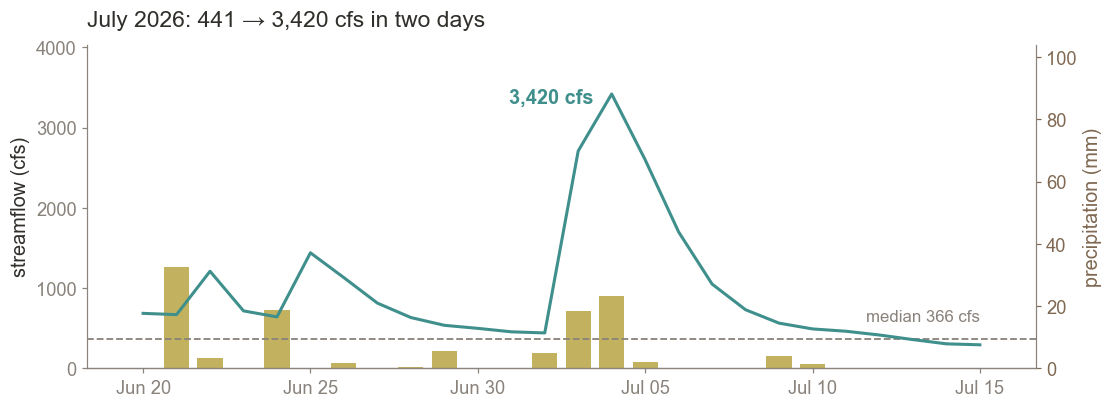

In [6]:
import matplotlib.dates as mdates

flood = f[(f.date >= "2026-06-20") & (f.date <= "2026-07-15")]
median = f.streamflow_t.median()

fig, ax = plt.subplots(figsize=WIDE)

# precipitation behind the hydrograph, on its own scale and compressed into the
# lower third so it reads as context rather than competing with the flow line
rain = ax.twinx()
rain.bar(flood.date, flood.precip_mm, color=GOLD, width=.75, zorder=1)
rain.set_ylim(0, flood.precip_mm.max() * 3.2)
rain.set_ylabel("precipitation (mm)", color=BROWN)
rain.tick_params(axis="y", colors=BROWN)
rain.spines[["top", "left"]].set_visible(False)
rain.spines["right"].set_visible(True); rain.spines["right"].set_color(MUTED)

ax.plot(flood.date, flood.streamflow_t, color=TEAL, zorder=3)
ax.axhline(median, color=MUTED, lw=1.2, ls="--", zorder=2)
ax.set_ylabel("streamflow (cfs)")
ax.set_ylim(0, flood.streamflow_t.max() * 1.18)
ax.set_zorder(rain.get_zorder() + 1); ax.patch.set_visible(False)

# annotate the peak rather than labelling the median inline, which sat on top
# of the rising limb
peak_i = flood.streamflow_t.idxmax()
ax.annotate(f"{flood.streamflow_t.max():,.0f} cfs",
            xy=(flood.date[peak_i], flood.streamflow_t[peak_i]),
            xytext=(-12, -6), textcoords="offset points",
            ha="right", color=TEAL, fontweight="bold")
ax.text(flood.date.iloc[-1], median * 1.6, f"median {median:,.0f} cfs",
        color=MUTED, ha="right", fontsize=11)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.set_title("July 2026: 441 → 3,420 cfs in two days")
save(fig, "flood_hydrograph"); plt.show()

first, why the distribution test cannot see it. psi over a window ending at the
peak, as the window widens:

   7d window: psi(streamflow)  3.33   share 75%


  14d window: psi(streamflow)  0.95   share 50%


  30d window: psi(streamflow)  0.50   share 50%


  60d window: psi(streamflow)  0.40   share 0%


  90d window: psi(streamflow)  0.19   share 0%


  saved reports/figures/psi_dilution.png


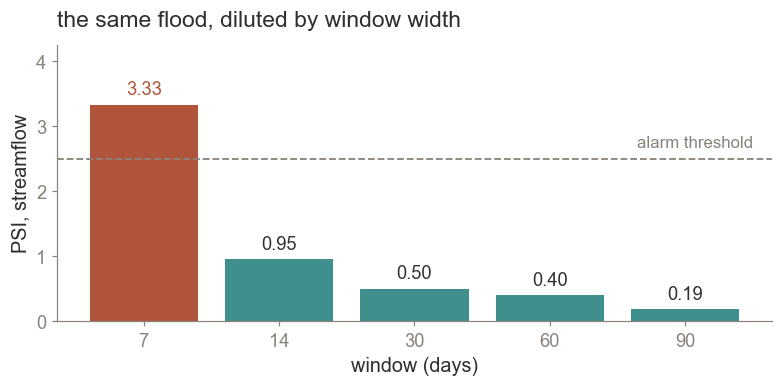

In [7]:
s_all = monitor.score_range("2015-01-01", model=current_model, features=f)
m = monitor.with_predictions(f, s_all)
peak = pd.Timestamp("2026-07-04")

dilution = []
for w in (7, 14, 30, 60, 90):
    cur_w = m[(m.date <= peak) & (m.date > peak - pd.Timedelta(days=w))]
    ref_w = monitor.seasonal_reference(m, cur_w)
    if len(ref_w) < 30: continue
    d = monitor.drift_report(ref_w, cur_w)
    psi_w = d["per_column_psi"].get("streamflow_t", 0)
    dilution.append((w, psi_w))
    print(f"  {w:2d}d window: psi(streamflow) {psi_w:5.2f}   share {d['drift_share']:.0%}")

thr = MON["psi_thresholds"]["streamflow_t"]
ws, ps = zip(*dilution)

fig, ax = plt.subplots(figsize=HALF)
bars = ax.bar([str(w) for w in ws], ps, color=[CLAY if p > thr else TEAL for p in ps])
ax.axhline(thr, color=MUTED, lw=1.2, ls="--")
ax.set_ylim(0, max(ps) * 1.28)                     # headroom so labels never clip
ax.text(len(ws) - .5, thr * 1.05, "alarm threshold", color=MUTED,
        ha="right", va="bottom", fontsize=11)
for b, p in zip(bars, ps):
    ax.text(b.get_x() + b.get_width() / 2, p + max(ps) * .03, f"{p:.2f}",
            ha="center", va="bottom", fontsize=12,
            color=CLAY if p > thr else INK)
ax.set_xlabel("window (days)")
ax.set_ylabel("PSI, streamflow")
ax.set_title("the same flood, diluted by window width")
save(fig, "psi_dilution"); plt.show()

two days of record flow are diluted by eighty-eight ordinary ones. shortening the
window is not the answer either - the null test above showed psi crossing 0.2 on
98.5% of 30-day draws with no drift present, so a short window fires in quiet
weather too.

so an event is detected **as an event**: today's flow against the 99th percentile
of the same season in recent years. this fires on 1.0% of days over the last 6.5
years - 9 distinct high-flow events, which is what this river actually does.

In [8]:
for day in ("2026-07-02", "2026-07-03", "2026-07-04", "2026-07-06", "2026-07-25"):
    a = monitor.anomaly(m, pd.Timestamp(day))
    pi_d = monitor.rolling_pi(s_all[s_all.date <= day]).iloc[-1]
    dec = monitor.decide(float(pi_d), {"passed": True}, event=a,
                         system={"model_age_days": 2.0, "nonfinite_predictions": 0})
    print(f"  {day}  flow {a['flow']:7.0f}  seasonal p99 {a['seasonal_p99']:7.0f}  "
          f"pi {pi_d:+.3f}  ->  {dec['status']} / {dec['action']}")

  2026-07-02  flow     441  seasonal p99    3501  pi +0.393  ->  ok / none
  2026-07-03  flow    2710  seasonal p99    3427  pi +0.393  ->  ok / none
  2026-07-04  flow    3420  seasonal p99    3375  pi +0.387  ->  anomaly / flag_only
  2026-07-06  flow    1700  seasonal p99    3396  pi +0.409  ->  ok / none
  2026-07-25  flow     168  seasonal p99    5376  pi +0.366  ->  ok / none


**the event flags, performance does not move, so nothing retrains.** the flood is
logged as evidence for a human to look at. note the receding limb on the 6th is
already quiet - this flags the event, not the whole month.

### scenario 3 - a season the model has never seen: sustained loss -> retrain

train on january only, then serve it through the rest of the year. this is the
failure the whole project is about: not a crash, just a model quietly describing
a world that no longer exists.

In [9]:
stale_model = fit(f[(f.date >= "2026-01-01") & (f.date < "2026-02-01")])
s_stale = monitor.score_range("2026-02-01", model=stale_model, features=f)
pi_stale = monitor.rolling_pi(s_stale)

from streamflow.tune import nash_sutcliffe_efficiency as nse
jun = s_stale[(s_stale.date >= "2026-06-01") & (s_stale.date < "2026-07-01")]
print(f"june, stale model:  nse {nse(jun.actual, jun.prediction):+.3f}   "
      f"pi {monitor.persistence_index(jun):+.3f}")
print("nse reads 'degraded but working'; pi says four times worse than doing nothing.\n")

d_stale = monitor.decide(float(pi_stale.dropna().iloc[-1]), {"passed": True},
                         system={"model_age_days": 5.0, "nonfinite_predictions": 0})
print(f"rolling pi (90d): {pi_stale.dropna().iloc[-1]:.3f}")
print(f"decision: {d_stale['status']} -> {d_stale['action']}")
print(f"          {d_stale['reason']}")

june, stale model:  nse -0.044   pi -3.040
nse reads 'degraded but working'; pi says four times worse than doing nothing.

rolling pi (90d): -2.402
decision: performance_drift -> retrain
          rolling PI -2.402 < 0.000 (worse than persistence)


  saved reports/figures/pi_healthy_vs_stale.png


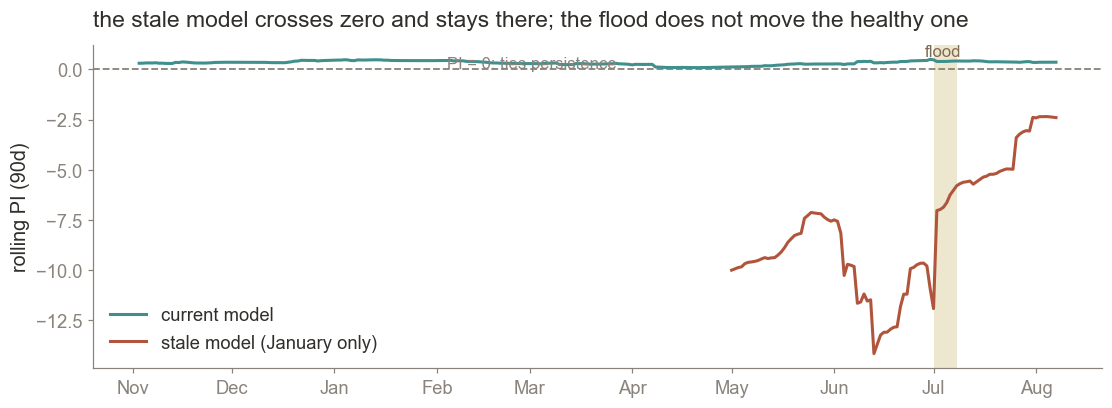

In [10]:
fig, ax = plt.subplots(figsize=WIDE)
ax.axvspan(pd.Timestamp("2026-07-01"), pd.Timestamp("2026-07-08"),
           color=GOLD, alpha=.30, lw=0, zorder=1)
ax.plot(s_ok.date, monitor.rolling_pi(s_ok), color=TEAL, label="current model", zorder=3)
ax.plot(s_stale.date, pi_stale, color=CLAY, label="stale model (January only)", zorder=3)
ax.axhline(0, color=MUTED, lw=1.2, ls="--", zorder=2)

lo, hi = ax.get_ylim()
ax.text(pd.Timestamp("2026-07-04"), hi, "flood", color=BROWN,
        ha="center", va="top", fontsize=11)
ax.text(s_stale.date.iloc[3], 0.06, "PI = 0: ties persistence", color=MUTED, fontsize=11)

ax.set_ylabel(f"rolling PI ({MON['pi_window_days']}d)")
ax.legend(loc="lower left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_title("the stale model crosses zero and stays there; "
             "the flood does not move the healthy one")
save(fig, "pi_healthy_vs_stale"); plt.show()

the flood (shaded) barely dents the healthy model - a spike in the inputs is not a
spike in error. the stale model crosses zero and **stays** there, which is what a
sustained loss looks like.

### scenario 4 - the clock: retrain on age alone

ml test score, monitor 4: *"models are not too stale"*. a model can be fine today
and still be overdue - if nothing has forced a retrain in 30 days, that is itself
a risk, and retrains here are cheap.

In [11]:
for age in (5, 29, 31, 120):
    d = monitor.decide(0.35, {"passed": True},
                       system={"model_age_days": age, "nonfinite_predictions": 0})
    print(f"  model age {age:4d}d -> {d['status']:<12} {d['action']}")
print(f"\nlimit: {MON['max_model_age_days']}d (config monitoring.max_model_age_days)")

  model age    5d -> ok           none
  model age   29d -> ok           none
  model age   31d -> model_stale  retrain
  model age  120d -> model_stale  retrain

limit: 30d (config monitoring.max_model_age_days)


### the system pillar

session 7: *"most failures are not model failures, they are system failures."*
recorded every run, healthy or not - a slow leak in latency or a creeping model
age is only visible as a trend.

In [12]:
import time
t0 = time.perf_counter()
s_sys = monitor.score_range("2026-01-01", model=current_model, features=f)
health = monitor.system_health(s_sys, time.perf_counter() - t0)
for k, v in health.items():
    print(f"  {k:24s} {v}")

  rows_scored              219
  duration_s               0.045
  rows_per_s               4883.8
  nonfinite_predictions    0
  model_age_days           nan


the same signals resolve differently. a model emitting nan is *broken*, not stale,
so it is investigated rather than retrained; a bad feed outranks everything,
because retraining cannot fix an input feed.

In [13]:
cases = {
    "healthy":              dict(pi_value=0.35, quality={"passed": True},
                                 system={"model_age_days": 3, "nonfinite_predictions": 0}),
    "flood (event)":        dict(pi_value=0.35, quality={"passed": True},
                                 event={"is_anomaly": True, "flow": 3420.0,
                                        "seasonal_p99": 3375.0, "times_p99": 1.01},
                                 system={"model_age_days": 3, "nonfinite_predictions": 0}),
    "seasonal drift only":  dict(pi_value=0.35, quality={"passed": True},
                                 drift={"dataset_drift": True, "drift_share": 0.25},
                                 system={"model_age_days": 3, "nonfinite_predictions": 0}),
    "stale model":          dict(pi_value=-0.42, quality={"passed": True},
                                 system={"model_age_days": 5, "nonfinite_predictions": 0}),
    "overdue by the clock": dict(pi_value=0.35, quality={"passed": True},
                                 system={"model_age_days": 99, "nonfinite_predictions": 0}),
    "nan predictions":      dict(pi_value=0.30, quality={"passed": True},
                                 system={"model_age_days": 3, "nonfinite_predictions": 7}),
    "model age unknown":    dict(pi_value=0.30, quality={"passed": True},
                                 system={"model_age_days": float("nan"), "nonfinite_predictions": 0}),
    "broken feed":          dict(pi_value=-9.0, quality={"passed": False, "reason": "stale feed"},
                                 drift={"dataset_drift": True, "drift_share": 1.0},
                                 system={"model_age_days": 99, "nonfinite_predictions": 7}),
    "span too short":       dict(pi_value=float("nan"), quality={"passed": True},
                                 system={"model_age_days": 3, "nonfinite_predictions": 0}),
}
out = [{"scenario": k, **{kk: monitor.decide(**v)[kk] for kk in ("status", "action")}}
       for k, v in cases.items()]
print(pd.DataFrame(out).to_string(index=False))

            scenario               status       action
             healthy                   ok         none
       flood (event)              anomaly    flag_only
 seasonal drift only           data_drift    flag_only
         stale model    performance_drift      retrain
overdue by the clock          model_stale      retrain
     nan predictions               system  investigate
   model age unknown               system  investigate
         broken feed         data_quality reject_input
      span too short insufficient_history         none


note the last two rows. an unknown model age is **not** treated as fresh, and a
span too short to fill the pi window reports `insufficient_history`, not `ok` - a
monitor that never ran must never look like a clean bill of health.

### corruption stress test

the brief asks for artificially corrupted inputs. two defence layers: the api
contract rejects out-of-range and schema violations outright (pydantic bounds in
`streamflow/serve.py`), and evidently catches shifts that are *valid* but wrong.

first the calibration - the same report over known-clean historical windows,
which has to stay quiet before any alarm from it means anything.

In [14]:
clean = []
for end in pd.date_range("2019-06-01", "2026-06-01", freq="6MS"):
    cur = m[(m.date <= end) & (m.date > end - pd.Timedelta(days=MON["drift_window_days"]))]
    ref = monitor.seasonal_reference(m, cur)
    if len(cur) < 30 or len(ref) < 30: continue
    d = monitor.drift_report(ref, cur)
    clean.append({"window_end": end.date(), "share": d["drift_share"], "alarm": d["dataset_drift"],
                  **{c: round(d["per_column_psi"].get(c, np.nan), 2) for c in MON["watch_columns"]}})
clean = pd.DataFrame(clean)
print(clean.to_string(index=False))
print(f"\nclean windows alarming: {clean.alarm.sum()} / {len(clean)}")
print(f"per-column clean max vs configured threshold:")
for c in MON["watch_columns"]:
    print(f"  {c:14s} max {clean[c].max():.2f}   threshold {MON['psi_thresholds'][c]}")

window_end  share  alarm  streamflow_t  precip_mm  tmax_c  tmin_c
2019-06-01    0.0  False          0.56       0.32    0.15    0.21
2019-12-01    0.0  False          1.34       0.15    0.24    0.19
2020-06-01    0.0  False          0.40       0.22    0.33    0.50
2020-12-01    0.0  False          0.79       0.16    0.38    0.78
2021-06-01    0.0  False          1.31       0.20    0.31    0.42
2021-12-01    0.0  False          0.59       0.17    0.11    0.16
2022-06-01    0.0  False          0.38       0.16    0.07    0.08
2022-12-01    0.0  False          0.66       0.43    0.12    0.36
2023-06-01    0.0  False          0.25       0.16    0.10    0.45
2023-12-01    0.0  False          0.78       0.06    0.12    0.15
2024-06-01    0.0  False          0.59       0.09    0.40    0.62
2024-12-01    0.0  False          0.80       0.28    0.47    0.53
2025-06-01    0.0  False          1.12       0.16    0.33    0.56
2025-12-01    0.0  False          1.09       0.08    0.13    0.34
2026-06-01

In [15]:
cur = m[m.date > m.date.max() - pd.Timedelta(days=MON["drift_window_days"])]
ref = monitor.seasonal_reference(m, cur)

rows = [{"scenario": "clean (control)", **monitor.drift_report(ref, cur)}]
for label, col, fn in [("-15 C temperature", "tmax_c", lambda s: s - 15),
                       ("5x rainfall",       "precip_mm", lambda s: s * 5),
                       ("gauge reads 10x",   "streamflow_t", lambda s: s * 10)]:
    c2 = cur.copy(); c2[col] = fn(c2[col])
    rows.append({"scenario": label, **monitor.drift_report(ref, c2)})

print(pd.DataFrame([{ "scenario": r["scenario"], "share": f"{r['drift_share']:.0%}",
                      "alarm": r["dataset_drift"],
                      "psi": {k: round(v, 2) for k, v in r["per_column_psi"].items()
                              if k in MON["watch_columns"]} } for r in rows]).to_string(index=False))

         scenario share  alarm                                                                       psi
  clean (control)    0%  False {'streamflow_t': 0.18, 'precip_mm': 0.12, 'tmax_c': 0.37, 'tmin_c': 0.25}
-15 C temperature   25%   True {'streamflow_t': 0.18, 'precip_mm': 0.12, 'tmax_c': 7.73, 'tmin_c': 0.25}
      5x rainfall   25%   True {'streamflow_t': 0.18, 'precip_mm': 0.83, 'tmax_c': 0.37, 'tmin_c': 0.25}
  gauge reads 10x   25%   True {'streamflow_t': 3.23, 'precip_mm': 0.12, 'tmax_c': 0.37, 'tmin_c': 0.25}


0/15 clean windows alarm and all three corruptions are caught. the share counts
only the four watched **inputs** - target and prediction have no calibrated
threshold, and counting them would hold the share permanently at 2/6 and let the
alarm fire on columns that were never validated.

the reference matters as much as the test: against a plain calendar window the
same current data reads psi 0.57 purely from the season, and against unlimited
history 1.41 (decades of changed river regime) - versus 0.13 for the
season-matched, recent-years reference actually used.

### the retrain is a candidate, not a deployment

a retrain fired by monitoring can be triggered on inputs that are valid but
wrong - usgs `ESTIMATED` and `ICE` qualifiers pass validation - so the candidate
has to win before it serves. both models are re-scored on the **same** hold-out:
the champion's own recorded metric describes whatever window existed when it was
fitted.

In [16]:
from streamflow import registry

for r in registry.history():
    mark = "-> serving" if r["champion"] else ""
    print(f"  v{r['version']:<3} pi {r['pi']:+.4f}  promoted={r['promoted']:<5} {mark}")

  v4   pi +0.3288  promoted=true  -> serving
  v3   pi -6.0157  promoted=false 
  v2   pi +0.3170  promoted=true  
  v1   pi +0.3170  promoted=true  


v3 is a deliberately crippled retrain, standing in for one triggered on bad data.
it is registered for audit and never served:

```
REJECTED v3: candidate pi -6.0157 loses to champion +0.3170 (margin -6.3328, tolerance 0.02)
  champion v2 stays deployed
```

under a newest-run-wins rule that model would be in production right now, while
the alert log recorded the retrain as remediation.

In [17]:
tol = registry.PROMOTION["tolerance"]
for label, cand, champ in [("clear improvement", 0.38, 0.32),
                           ("identical retrain",  0.32, 0.32),
                           ("noise-level dip",    0.31, 0.32),
                           ("real regression",    0.10, 0.32),
                           ("model emits nan",    float("nan"), 0.32)]:
    v = registry.compare({"pi": cand}, {"pi": champ}, tolerance=tol)
    print(f"  {label:<19} {'PROMOTE' if v['promote'] else 'REJECT ':<8} {v['reason']}")

  clear improvement   PROMOTE  candidate pi +0.3800 beats champion +0.3200 (margin +0.0600, tolerance 0.02)
  identical retrain   PROMOTE  candidate pi +0.3200 beats champion +0.3200 (margin +0.0000, tolerance 0.02)
  noise-level dip     PROMOTE  candidate pi +0.3100 is within tolerance of champion +0.3200 (margin -0.0100, tolerance 0.02)
  real regression     REJECT   candidate pi +0.1000 loses to champion +0.3200 (margin -0.2200, tolerance 0.02)
  model emits nan     REJECT   candidate pi is not finite


rollback is one call and skips rejected candidates - counting back by version
number would redeploy the model the gate just refused. recovery does not depend
on the training pipeline being healthy.

### the alert log

every decision is recorded, including the quiet ones - a log of only failures
cannot show a stable baseline, and drift evidence that is not queryable is not
evidence.

In [18]:
log = pd.read_parquet("../" + MON["alerts_path"])
print(log[["as_of", "status", "action", "pi", "drift_evaluated", "drift_share",
           "model_age_days", "rows_scored"]].tail(8).to_string(index=False))

     as_of status action       pi  drift_evaluated  drift_share  model_age_days  rows_scored
2026-08-05     ok   none 0.368836             True          0.0            0.04        30138
2026-08-05     ok   none 0.368836             True          0.0            0.04            1
2026-08-07     ok   none 0.353474             True          0.0            0.00        30140


### takeaways

- **pi < 0 on a 90-day window** is the retrain trigger, calibrated on the same
  overlapping estimator the alarm uses: 0.6% false alarm, 3 spurious episodes in
  10.5 years, while a stale model breaches on 100% of days
- **events and drift never retrain.** the july flood is flagged and left alone -
  retraining there would teach a 3,420 cfs peak as normal
- **a 90-day psi window cannot see a 2-day flood** (psi 3.33 at 7d, 0.19 at 90d),
  so the event is detected as an event rather than as a distribution shift
- **nse would have missed it.** the stale model posts nse -0.04 (reads as
  "degraded but working") while pi says -3.04, four times worse than persistence
- **age is its own trigger.** a model can be accurate and still overdue
- **unmeasured is not healthy.** short spans and unknown model age report their
  own status rather than falling through to ok
- **a retrain still has to win.** the candidate is compared to the champion on
  the same window before the alias moves, so a retrain fired on a false alarm
  cannot degrade production

remaining gap: ml test score monitor 1 (dependency-change notification).
dependencies are pinned, but nothing watches them - see `docs/architecture.md`.